In [2]:
import time
import math
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.profiler import profile, ProfilerActivity

**Part 1: Measuring Compilation Overhead**

In [ ]:
def elementwise_pipeline(x):
    y = jnp.sin(x)
    y = jnp.cos(y)
    y = jnp.exp(y)
    y = jnp.log(jnp.abs(y) + 1.0)
    y = jnp.square(y)
    y = jnp.sqrt(y + 1e-6)
    y = jnp.tanh(y)
    y = jnp.abs(y)
    y = y + 2.0
    y = y / 3.0
    return y

jit_pipeline = jax.jit(elementwise_pipeline)

def timed_call(fn, x):
    start = time.perf_counter()
    y = fn(x)
    y.block_until_ready()
    end = time.perf_counter()
    return end - start

sizes = [(100, 100), (500, 500), (1000, 1000), (5000, 5000)]

eager_times = []
jit_first_times = []
jit_second_times = []

for shape in sizes:
    x = jax.random.normal(jax.random.PRNGKey(sum(shape)), shape)

    t_eager = timed_call(elementwise_pipeline, x)
    t_jit_first = timed_call(jit_pipeline, x)
    t_jit_second = timed_call(jit_pipeline, x)

    eager_times.append(t_eager)
    jit_first_times.append(t_jit_first)
    jit_second_times.append(t_jit_second)

    print(f"Shape {shape}: eager={t_eager:.6f}s, first_jit={t_jit_first:.6f}s, second_jit={t_jit_second:.6f}s")

Shape (100, 100): eager=0.001106s, first_jit=0.108896s, second_jit=0.000506s
Shape (500, 500): eager=0.016748s, first_jit=0.110691s, second_jit=0.005099s
Shape (1000, 1000): eager=0.067424s, first_jit=0.099739s, second_jit=0.019496s
Shape (5000, 5000): eager=1.936845s, first_jit=0.580577s, second_jit=0.504768s


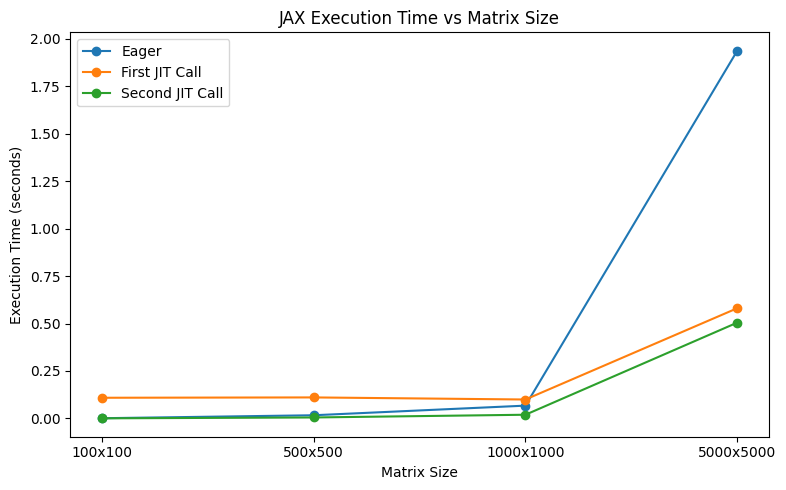

In [ ]:
labels = [f"{r}x{c}" for r, c in sizes]

plt.figure(figsize=(8, 5))
plt.plot(labels, eager_times, marker="o", label="Eager")
plt.plot(labels, jit_first_times, marker="o", label="First JIT Call")
plt.plot(labels, jit_second_times, marker="o", label="Second JIT Call")
plt.xlabel("Matrix Size")
plt.ylabel("Execution Time (seconds)")
plt.title("JAX Execution Time vs Matrix Size")
plt.legend()
plt.tight_layout()
plt.show()

**Part 2: Shape Specialization**

In [ ]:
@jax.jit
def row_mean(x):
    return jnp.mean(x, axis=1)

inputs = [
    jax.random.normal(jax.random.PRNGKey(0), (100, 100)),
    jax.random.normal(jax.random.PRNGKey(1), (100, 200)),
    jax.random.normal(jax.random.PRNGKey(2), (100, 100)),
    jax.random.normal(jax.random.PRNGKey(3), (200, 100)),
]

call_labels = ["(100,100)", "(100,200)", "(100,100) again", "(200,100)"]
shape_times = []

for label, x in zip(call_labels, inputs):
    start = time.perf_counter()
    y = row_mean(x)
    y.block_until_ready()
    end = time.perf_counter()
    shape_times.append(end - start)
    print(f"{label}: {end - start:.6f}s")

(100,100): 0.061856s
(100,200): 0.066649s
(100,100) again: 0.000134s
(200,100): 0.067369s


Shape: (100, 100)
{ lambda ; a:f32[100,100]. let
    b:f32[100] = reduce_sum[axes=(1,)] a
    c:f32[100] = div b 100.0:f32[]
  in (c,) }
--------------------------------------------------------------------------------
Shape: (100, 200)
{ lambda ; a:f32[100,200]. let
    b:f32[100] = reduce_sum[axes=(1,)] a
    c:f32[100] = div b 200.0:f32[]
  in (c,) }
--------------------------------------------------------------------------------
Shape: (100, 100)
{ lambda ; a:f32[100,100]. let
    b:f32[100] = reduce_sum[axes=(1,)] a
    c:f32[100] = div b 100.0:f32[]
  in (c,) }
--------------------------------------------------------------------------------
Shape: (200, 100)
{ lambda ; a:f32[200,100]. let
    b:f32[200] = reduce_sum[axes=(1,)] a
    c:f32[200] = div b 100.0:f32[]
  in (c,) }
--------------------------------------------------------------------------------


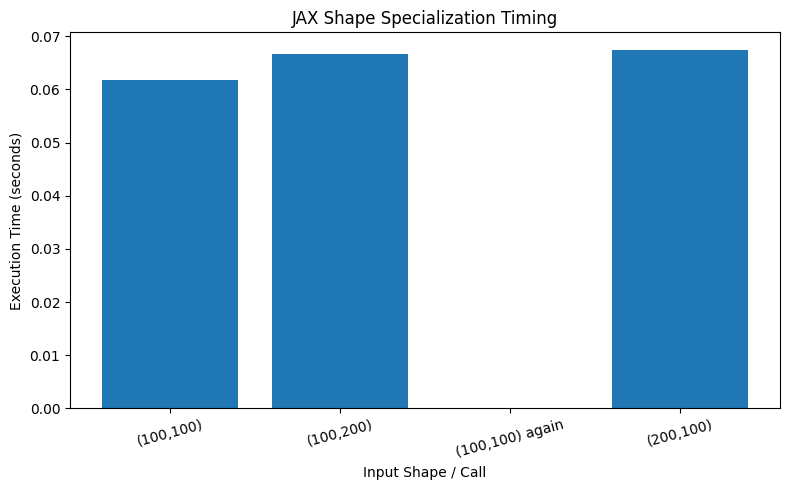

In [ ]:
for x in inputs:
    print("Shape:", x.shape)
    print(jax.make_jaxpr(lambda z: jnp.mean(z, axis=1))(x))
    print("-" * 80)

plt.figure(figsize=(8, 5))
plt.bar(call_labels, shape_times)
plt.xlabel("Input Shape / Call")
plt.ylabel("Execution Time (seconds)")
plt.title("JAX Shape Specialization Timing")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Part 3: Operator Fusion Analysis**

In [3]:
def apply_sin_i_times(x, i):
    y = x
    for _ in range(i):
        y = jnp.sin(y)
    return y

def apply_cos_i_times(x, i):
    y = x
    for _ in range(i):
        y = jnp.cos(y)
    return y

def fusion_version_a(x):
    result = jnp.zeros_like(x)
    for i in range(1, 101):
        term1 = apply_sin_i_times(x, i)
        term2 = apply_cos_i_times(x, i)
        term = term1 + term2
        result = result + term
    return result

@jax.jit
def fusion_version_b(x):
    return sum(
        apply_sin_i_times(x, i) + apply_cos_i_times(x, i)
        for i in range(1, 101)
    )

In [4]:
x = jnp.ones((8, 8), dtype=jnp.float32)

y_a = fusion_version_a(x)
y_b = fusion_version_b(x)
y_b.block_until_ready()

print("Max difference:", jnp.max(jnp.abs(y_a - y_b)))

def bench(fn, x, warmup=2, runs=5):
    for _ in range(warmup):
        y = fn(x)
        y.block_until_ready()

    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        y = fn(x)
        y.block_until_ready()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return np.mean(times), np.std(times)

x = jnp.ones((1024, 1024), dtype=jnp.float32)

mean_a, std_a = bench(fusion_version_a, x, warmup=1, runs=3)
mean_b, std_b = bench(fusion_version_b, x, warmup=2, runs=5)

print("Version A time:", mean_a, "+/-", std_a)
print("Version B time:", mean_b, "+/-", std_b)

Max difference: 0.0
Version A time: 0.715704506666801 +/- 0.056991573145571114
Version B time: 0.013710927400006767 +/- 4.52643917462562e-05


In [5]:
def profile_once(fn, x):
    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        profile_memory=True,
        record_shapes=False
    ) as prof:
        y = fn(x)
        y.block_until_ready()
    return prof

# warm up JIT first
_ = fusion_version_b(x).block_until_ready()

prof_a = profile_once(fusion_version_a, x)
prof_b = profile_once(fusion_version_b, x)

print("=== Version A ===")
print(prof_a.key_averages().table(sort_by="self_cuda_time_total", row_limit=20))

print("=== Version B ===")
print(prof_b.key_averages().table(sort_by="self_cuda_time_total", row_limit=20))

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


=== Version A ===
------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem    # of Calls  
------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                      wrapped_cosine         0.00%       0.000us         0.00%       0.000us       0.000us     181.394ms        48.69%     181.394ms      35.920us           0 B           0 B          5050  
                        wrapped_sine         0.00%       0.000us         0.00%       0.000us       0.000us     180.317ms        48.41%     180.317ms     

In [9]:
numel = 1024 * 1024
bytes_per_tensor = numel * 4   # float32

# Version A:
# 5050 sin, 5050 cos, 200 add, 1 broadcast
# unary op: 1 read + 1 write = 2 tensor transfers
# add op: 2 reads + 1 write = 3 tensor transfers
traffic_a = (5050 * 2 + 5050 * 2 + 200 * 3 + 1) * bytes_per_tensor

# Version B:
# fused ideal case: 1 read x + 1 write y
traffic_b = 2 * bytes_per_tensor

cuda_time_a = 372.511e-3
cuda_time_b = 13.371e-3

throughput_a = traffic_a / cuda_time_a / 1e9
throughput_b = traffic_b / cuda_time_b / 1e9

print("Estimated effective throughput A (GB/s):", throughput_a)
print("Estimated effective throughput B (GB/s):", throughput_b)

Estimated effective throughput A (GB/s): 234.20977502409326
Estimated effective throughput B (GB/s): 0.627373270510807
